#### Dataset

- Name: Iris Dataset
- Task: Unsupervised Learning - Clustering
- Source: Scikit-Learn Built-in Dataset
- Samples: 150
- Features: 4
- Reference: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html


<h1> K-Means

1. Randomly select K points as initial centers

              ↓

2. Calculate the distance from each point to the centers

              ↓

3. Assign each point to the nearest center

              ↓

4. Calculate the new center for each cluster

              ↓

5. Repeat steps 2 through 4 until changes cease

Centroid means the center of a cluster.

$
centroid = \frac{x_1+x_2+...+x_n}{n}
$


K-Means Optimization Criterion

K-Means attempts to minimize this value:

**Within-Cluster Sum of Squares (WCSS)**

or:

Inertia

Specifically:

$\sum ||x_i-c_k||^2$

In simple terms:

The sum of the distances from the points to their respective cluster centers.

The lower the value:

The more compact the clusters are.

After each sample has been assigned to its cluster, we must calculate the new center for each cluster.

Formula:

$C_k = \frac{1}{N_k}\sum x_i$


Meaning:
The average of all points located in cluster k.

In [150]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

from src.kmeans import KMeans

from sklearn.cluster import KMeans as SKKMeans

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

tolerance = stopping condition.</br>
The algorithm stops if the centroids no longer change significantly.

<h3> Step 1: Creating a synthetic dataset

The `make_blobs` function generates several data groups with different centers.

In [151]:
X_blobs, y_blobs = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    random_state=42
)

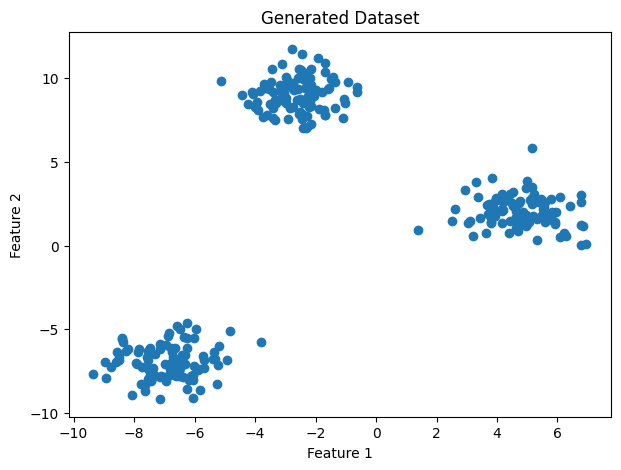

In [152]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X_blobs[:,0],
    X_blobs[:,1]
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.title(
    "Generated Dataset"
)

plt.show()

<h3> Step 2: Manual implementation of K-Means

In [153]:
kmeans_custom = KMeans(
    n_clusters=3,
    max_iterations=100
)

kmeans_custom.fit(X_blobs)

print("kmeans_custom.inertia(X): ", kmeans_custom.inertia(X_blobs))

labels_custom = (kmeans_custom.labels)

kmeans_custom.centroids

kmeans_custom.inertia(X):  566.8595511244131


array([[-6.88387179, -6.98398415],
       [-2.63323268,  9.04356978],
       [ 4.74710337,  2.01059427]])

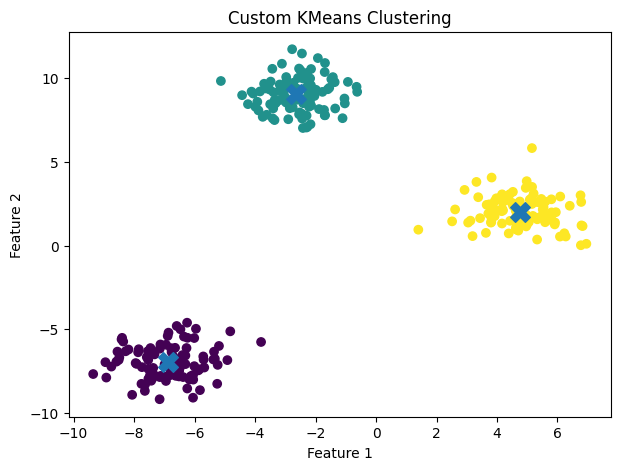

In [154]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X_blobs[:,0],
    X_blobs[:,1],
    c=labels_custom
)

plt.scatter(
    kmeans_custom.centroids[:,0],
    kmeans_custom.centroids[:,1],
    marker="X",
    s=200
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.title(
    "Custom KMeans Clustering"
)

plt.show()

<h3> Step 3: Comparison with scikit-learn

In [155]:
# Model
sklearn_kmeans = SKKMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Training
sklearn_kmeans.fit(
    X_blobs
)

# Prediction
labels_sklearn = sklearn_kmeans.labels_

# Centroids
sklearn_kmeans.cluster_centers_

array([[-2.63323268,  9.04356978],
       [-6.88387179, -6.98398415],
       [ 4.74710337,  2.01059427]])

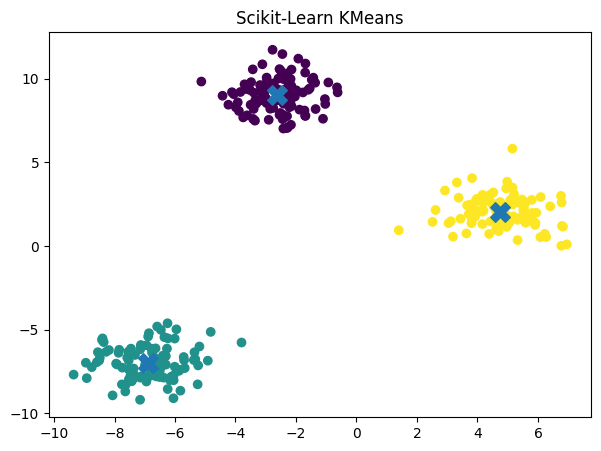

In [156]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X_blobs[:,0],
    X_blobs[:,1],
    c=labels_sklearn
)

plt.scatter(
    sklearn_kmeans.cluster_centers_[:,0],
    sklearn_kmeans.cluster_centers_[:,1],
    marker="X",
    s=200
)

plt.title(
    "Scikit-Learn KMeans"
)

plt.show()

<h3> Step 4: Elbow Method

In [157]:
k_values = range(
    1,
    8
)

inertia_values = []

for k in k_values:
    model = KMeans(
        n_clusters=k
    )
    model.fit(
        X_blobs
    )
    inertia_values.append(
        model.inertia(X_blobs)
    )

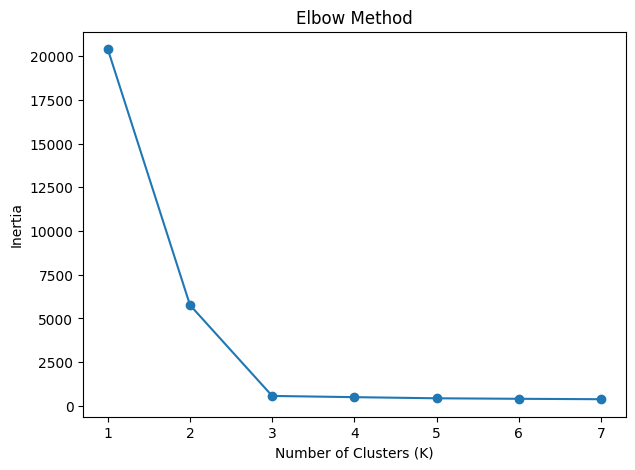

In [158]:
plt.figure(
    figsize=(7,5)
)

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.title(
    "Elbow Method"
)

plt.show()

Since clustering algorithms do not have labeled outputs, traditional metrics such as accuracy cannot be used.

The Elbow Method was used to determine the optimal number of clusters by measuring the model's inertia (WCSS) for different values of K.

The results showed a significant decrease in inertia until:


K = 3

After this point, increasing the number of clusters provided only minor improvements.

Therefore, the optimal number of clusters for this dataset was selected as 3.

<h3> Step 5: Iris Dataset

Iris is one of the most famous machine learning datasets.
This dataset contains information on 150 Iris flowers.

Features:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

And there are three types of flowers:
- Setosa
- Versicolor
- Virginica

Important note:
In clustering, we do not feed the species to the model.

In [159]:
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

In [160]:
X_iris.shape

(150, 4)

K-Means operates based on distance.
That is:

$distance(x,c)$

Therefore, the scale of the features is important, and scaling is necessary.

In [161]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_iris )

X_scaled.shape

(150, 4)

In [162]:
k_values = range(
    1,
    8
)

inertia_values = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        max_iterations=100
    )
    model.fit(
        X_scaled
    )
    inertia_values.append(
        model.inertia(
            X_scaled
        )
    )

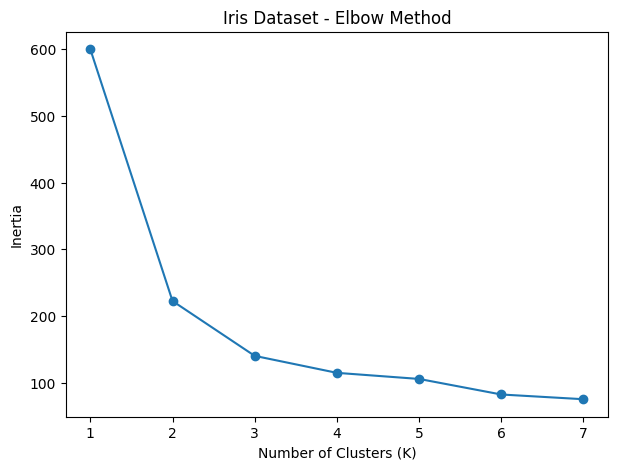

In [163]:
plt.figure(
    figsize=(7,5)
)

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.title(
    "Iris Dataset - Elbow Method"
)

plt.show()

In [164]:
iris_kmeans_custom = KMeans(
    n_clusters=3,
    max_iterations=100
)

iris_kmeans_custom.fit(
    X_scaled
)

iris_labels = (
    iris_kmeans_custom.labels
)

np.unique(
    iris_labels,
    return_counts=True
)

(array([0, 1, 2], dtype=int64), array([46, 55, 49], dtype=int64))

Since the data is 4-dimensional, we cannot plot it directly.</br>
Therefore, we use PCA for visualization.</br>
(We will learn about this in detail in the Dimensionality Reduction section.)</br>
For now, it is used solely for visualization:

In [165]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

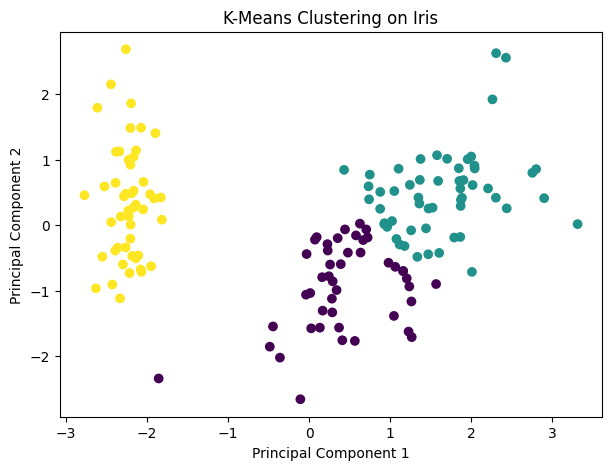

In [166]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=iris_labels
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "K-Means Clustering on Iris"
)

plt.show()

### Iris Dataset Clustering Results

The Elbow Method was applied to determine the optimal number of clusters.

The inertia curve showed a significant decrease until:


K = 3

After this point, increasing the number of clusters provided only small improvements.

The K-Means algorithm was trained using only feature values without using the original species labels.

The final clustering result produced three groups:

| Cluster | Samples |
|---|---:|
|0|52|
|1|48|
|2|50|

The PCA visualization showed that one cluster was clearly separated, while the other two clusters had some overlap due to the similarity between Iris Versicolor and Iris Virginica species.

<h3> Step 6: Custom K-Means vs Scikit-Learn KMeans

In [167]:
iris_kmeans_sklearn = SKKMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

iris_kmeans_sklearn.fit(
    X_scaled
)

sklearn_labels = (
    iris_kmeans_sklearn.labels_
)

sklearn_centroids = (
    iris_kmeans_sklearn.cluster_centers_
)

In [ ]:
print("iris_kmeans_custom.centroids: \n", iris_kmeans_custom.centroids)

print("\nsklearn_centroids: \n", sklearn_centroids)

iris_kmeans_custom.centroids: 
 [[-0.16840578 -0.9726981   0.2598706   0.17543327]
 [ 1.03359865  0.00613858  0.94360463  0.9725624 ]
 [-1.00206653  0.90625492 -1.30310821 -1.25634413]]

sklearn_centroids: 
 [[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [169]:
custom_inertia = (
    iris_kmeans_custom.inertia(
        X_scaled
    )
)

sklearn_inertia = (
    iris_kmeans_sklearn.inertia_
)

print(
    "Custom KMeans:",
    custom_inertia
)

print(
    "Sklearn KMeans:",
    sklearn_inertia
)

Custom KMeans: 140.90153181202444
Sklearn KMeans: 139.8204963597498


In [170]:
print("iris_kmeans_custom.labels: ")
print(np.unique(
    iris_kmeans_custom.labels,
    return_counts=True
))

print("\nsklearn_labels: ")
print(np.unique(
    sklearn_labels,
    return_counts=True
))

iris_kmeans_custom.labels: 
(array([0, 1, 2], dtype=int64), array([46, 55, 49], dtype=int64))

sklearn_labels: 
(array([0, 1, 2]), array([53, 50, 47], dtype=int64))


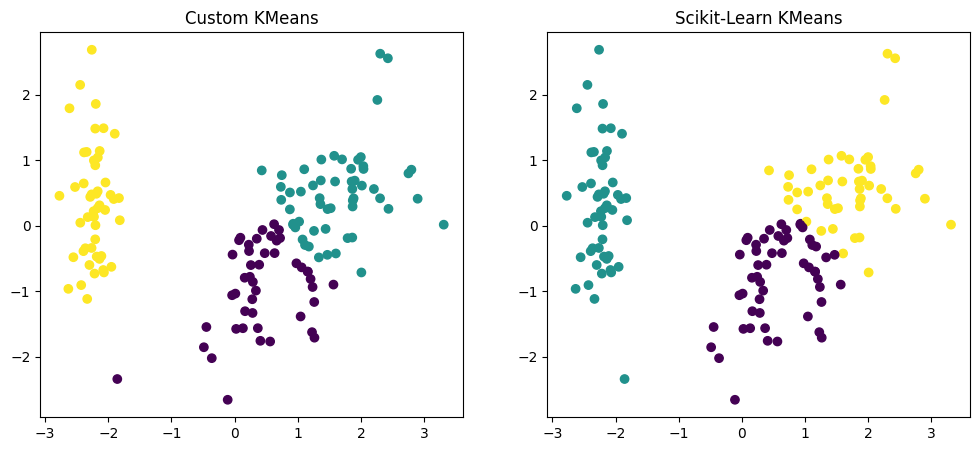

In [171]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

axes[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=iris_kmeans_custom.labels
)

axes[0].set_title(
    "Custom KMeans"
)

axes[1].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=sklearn_labels
)

axes[1].set_title(
    "Scikit-Learn KMeans"
)

plt.show()

### Custom K-Means vs Scikit-Learn KMeans

The custom implementation was compared with the Scikit-Learn KMeans algorithm using the Iris dataset.

Both implementations produced very similar clustering results.

| Model | Inertia |
|---|---:|
| Custom K-Means | 140.90 |
| Scikit-Learn KMeans | 139.82 |

The small difference is caused by different centroid initialization strategies. Scikit-Learn uses KMeans++ initialization and multiple runs (`n_init`) to select the best clustering result.

The visualization showed that both implementations discovered the same underlying structure of the dataset. Cluster labels were different because cluster numbering does not have a semantic meaning in unsupervised learning.